In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 7.9 MB/s eta 0:00:00


In [ ]:
import torch

x = torch.tensor(5.0, requires_grad=True) # x=5
f = x**2
g = 3*(x**3)
f.backward() # f'(x)=2x
#g.backward() # g'(x)=9x²
x.grad # f'(5)=10


tensor(10.)

In [ ]:
x = torch.tensor(5.0, requires_grad=True) # x=5
y = torch.tensor(4.0)
f = x**2 + y**3
f.backward()
x.grad

tensor(10.)

In [ ]:
y.grad

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)
X_test = torch.FloatTensor(X_test)
X_train = torch.FloatTensor(X_train)

y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [ ]:
X_train.shape, y_train.shape

(torch.Size([16512, 8]), torch.Size([16512, 1]))

In [ ]:
n_features = X_train.shape[1]
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [ ]:
lr = 0.1
n_epochs = 100
for epoch in range(n_epochs):
  y_pred = X_train @ w + b
  loss = ((y_pred - y_train)**2).mean()
  loss.backward()
  with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
  print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

Epoch 1/100, Loss: 0.550269603729248
Epoch 2/100, Loss: 0.5496746301651001
Epoch 3/100, Loss: 0.5490937829017639
Epoch 4/100, Loss: 0.5485267043113708
Epoch 5/100, Loss: 0.5479728579521179
Epoch 6/100, Loss: 0.5474322438240051
Epoch 7/100, Loss: 0.5469042658805847
Epoch 8/100, Loss: 0.5463886857032776
Epoch 9/100, Loss: 0.5458852052688599
Epoch 10/100, Loss: 0.5453934073448181
Epoch 11/100, Loss: 0.544913113117218
Epoch 12/100, Loss: 0.5444440245628357
Epoch 13/100, Loss: 0.543985903263092
Epoch 14/100, Loss: 0.5435382723808289
Epoch 15/100, Loss: 0.5431010723114014
Epoch 16/100, Loss: 0.5426739454269409
Epoch 17/100, Loss: 0.5422567129135132
Epoch 18/100, Loss: 0.5418490767478943
Epoch 19/100, Loss: 0.5414507389068604
Epoch 20/100, Loss: 0.5410616397857666
Epoch 21/100, Loss: 0.5406813621520996
Epoch 22/100, Loss: 0.5403097867965698
Epoch 23/100, Loss: 0.5399466753005981
Epoch 24/100, Loss: 0.5395918488502502
Epoch 25/100, Loss: 0.5392449498176575
Epoch 26/100, Loss: 0.538906097412109

In [ ]:
import torch.nn as nn

lr = 0.01
n_features = X_train.shape[1]
model = nn.Linear(n_features, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

def train_models(model, criterion, optimizer, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

train_models(model, criterion, optimizer, X_train, y_train, 100)

Epoch 1/100, Loss: 6.013651371002197
Epoch 2/100, Loss: 5.798527240753174
Epoch 3/100, Loss: 5.592207431793213
Epoch 4/100, Loss: 5.394321918487549
Epoch 5/100, Loss: 5.204513072967529
Epoch 6/100, Loss: 5.022443771362305
Epoch 7/100, Loss: 4.8477864265441895
Epoch 8/100, Loss: 4.68023157119751
Epoch 9/100, Loss: 4.519482135772705
Epoch 10/100, Loss: 4.3652544021606445
Epoch 11/100, Loss: 4.217275619506836
Epoch 12/100, Loss: 4.075286865234375
Epoch 13/100, Loss: 3.939039707183838
Epoch 14/100, Loss: 3.8082950115203857
Epoch 15/100, Loss: 3.682825803756714
Epoch 16/100, Loss: 3.5624139308929443
Epoch 17/100, Loss: 3.4468507766723633
Epoch 18/100, Loss: 3.3359360694885254
Epoch 19/100, Loss: 3.2294795513153076
Epoch 20/100, Loss: 3.1272969245910645
Epoch 21/100, Loss: 3.0292136669158936
Epoch 22/100, Loss: 2.935061454772949
Epoch 23/100, Loss: 2.844679355621338
Epoch 24/100, Loss: 2.75791335105896
Epoch 25/100, Loss: 2.6746151447296143
Epoch 26/100, Loss: 2.59464430809021
Epoch 27/100, 

In [ ]:
import torch
import torch.nn as nn

model_seq = nn.Sequential(
    nn.Linear(n_features, 40),
    nn.ReLU(),
    nn.BatchNorm1d(40),
    nn.Linear(40, 10),
    nn.ReLU(),
    nn.BatchNorm1d(10),
    nn.Linear(10, 1),
)

lr = 0.05
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_seq.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.001)

def fcn(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    nn.init.zeros_(module.bias)

model_seq.apply(fcn)


def train_models(model, criterion, optimizer, scheduler, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

train_models(model_seq, criterion, optimizer, scheduler, X_train, y_train, 300)

Epoch 1/300, Loss: 5.8975300788879395
Epoch 2/300, Loss: 3.9536659717559814
Epoch 3/300, Loss: 2.9115238189697266
Epoch 4/300, Loss: 2.167203664779663
Epoch 5/300, Loss: 1.6457369327545166
Epoch 6/300, Loss: 1.2969416379928589
Epoch 7/300, Loss: 1.072621464729309
Epoch 8/300, Loss: 0.9315409660339355
Epoch 9/300, Loss: 0.8432033658027649
Epoch 10/300, Loss: 0.7871599793434143
Epoch 11/300, Loss: 0.7506295442581177
Epoch 12/300, Loss: 0.7263185977935791
Epoch 13/300, Loss: 0.7097382545471191
Epoch 14/300, Loss: 0.6982351541519165
Epoch 15/300, Loss: 0.690202534198761
Epoch 16/300, Loss: 0.6846039295196533
Epoch 17/300, Loss: 0.6807877421379089
Epoch 18/300, Loss: 0.6782592535018921
Epoch 19/300, Loss: 0.676693320274353
Epoch 20/300, Loss: 0.6757698059082031
Epoch 21/300, Loss: 0.6752303242683411
Epoch 22/300, Loss: 0.6748213171958923
Epoch 23/300, Loss: 0.6742985248565674
Epoch 24/300, Loss: 0.673414945602417
Epoch 25/300, Loss: 0.6719577312469482
Epoch 26/300, Loss: 0.6697713136672974


In [ ]:
i= 10
model_seq(X_test)

tensor([[0.7084],
        [2.3456],
        [2.1836],
        ...,
        [2.9400],
        [3.5803],
        [2.3061]], grad_fn=<AddmmBackward0>)

In [ ]:
model_seq = nn.Sequential(
    nn.Dropout(p=0.2), nn.Linear(n_features, 40), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(40, 10), nn.ReLU(),
    nn.Linear(10, 1),
)

lr = 0.05
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_seq.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.001)


train_models(model_seq, criterion, optimizer, scheduler, X_train, y_train, 300)

Epoch 1/300, Loss: 7.215349197387695
Epoch 2/300, Loss: 5.562102317810059
Epoch 3/300, Loss: 4.391160488128662
Epoch 4/300, Loss: 3.3987128734588623
Epoch 5/300, Loss: 2.589836835861206
Epoch 6/300, Loss: 2.0311405658721924
Epoch 7/300, Loss: 1.697556734085083
Epoch 8/300, Loss: 1.5160462856292725
Epoch 9/300, Loss: 1.4213179349899292
Epoch 10/300, Loss: 1.3735032081604004
Epoch 11/300, Loss: 1.3443500995635986
Epoch 12/300, Loss: 1.286591649055481
Epoch 13/300, Loss: 1.2269662618637085
Epoch 14/300, Loss: 1.2309863567352295
Epoch 15/300, Loss: 1.198366641998291
Epoch 16/300, Loss: 1.1832274198532104
Epoch 17/300, Loss: 1.1721677780151367
Epoch 18/300, Loss: 1.1785345077514648
Epoch 19/300, Loss: 1.1562832593917847
Epoch 20/300, Loss: 1.1691248416900635
Epoch 21/300, Loss: 1.1649636030197144
Epoch 22/300, Loss: 1.1695953607559204
Epoch 23/300, Loss: 1.1486066579818726
Epoch 24/300, Loss: 1.1530357599258423
Epoch 25/300, Loss: 1.140271782875061
Epoch 26/300, Loss: 1.140538215637207
Epoc

In [ ]:
y_test[i]

tensor([0.9270])

In [ ]:
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_val_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
train_data, val_data = torch.utils.data.random_split(train_val_data, [55000, 5000])
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [ ]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_data, batch_size=32, shuffle=True)
val_dl = DataLoader(val_data, batch_size=32)
test_dl = DataLoader(test_data, batch_size=32)

In [ ]:
import torch

inputs = torch.randn(32, 3, 100, 200)
means = torch.randn(32, 3, 1, 1)

(inputs-means).shape

torch.Size([32, 3, 100, 200])

# Imágenes

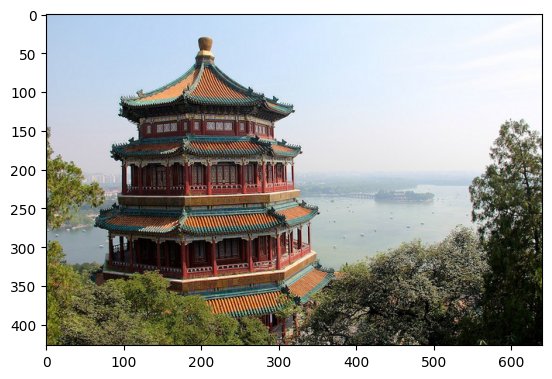

In [ ]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images
import matplotlib.pyplot as plt

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255
plt.imshow(sample_images[0])
plt.show()

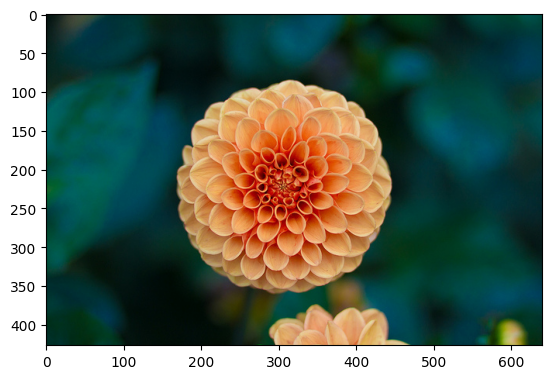

In [ ]:
plt.imshow(sample_images[1])
plt.show()

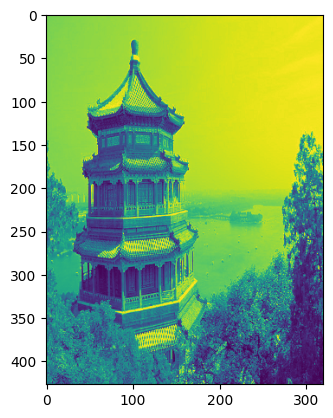

In [ ]:
import torch.nn as nn

new_image = nn.MaxPool2d(2, stride=2, padding=0)(sample_images[0])
plt.imshow(new_image)
plt.show()

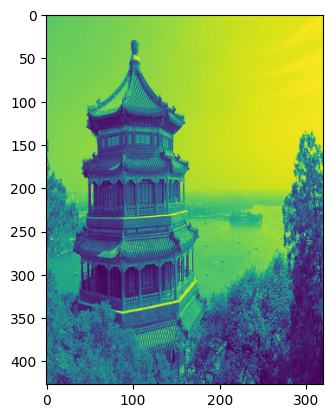

In [ ]:
new_image = nn.AvgPool2d(2, stride=2, padding=0)(sample_images[0])
plt.imshow(new_image)
plt.show()

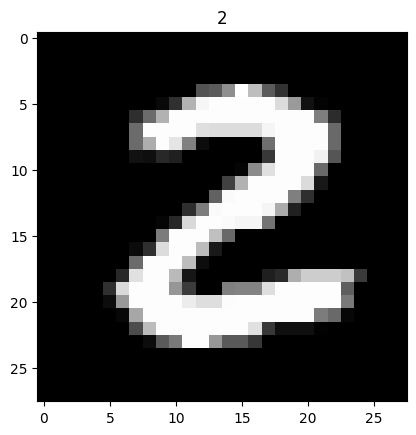

In [ ]:
from sklearn.datasets import fetch_openml

# if as_frame=True returns Pandas's dataframe, else returns Numpy arr
mnist = fetch_openml('mnist_784', as_frame=False)

X, y = mnist.data, mnist.target

n =25

ejemplo = X[n].reshape(28, 28)

plt.imshow(ejemplo, cmap="gray")
plt.title(y[n])
plt.show()

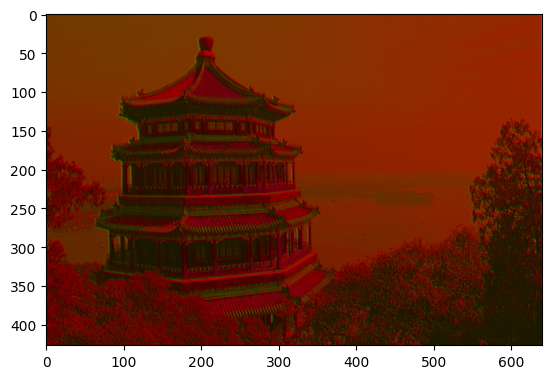

In [ ]:

cnn = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding="same")

with torch.no_grad():
  new_image = cnn(sample_images[0].permute(2,0,1))
  new_image = new_image.permute(1,2,0)
plt.imshow(new_image)
plt.show()

In [ ]:
import torch

cnn = torch.nn.Conv2d(in_channels=4,out_channels=4, kernel_size=3, groups=2)
cnn.weight.shape

torch.Size([4, 2, 3, 3])

In [ ]:
import torchvision
import torch

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
sorted(torchvision.models.list_models())

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

[name for name, child in model.named_children()]

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 172MB/s]


['features', 'avgpool', 'classifier']

In [ ]:
ds_train = torchvision.datasets.Flowers102(split="train", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())
ds_test = torchvision.datasets.Flowers102(split="test", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())
ds_val = torchvision.datasets.Flowers102(split="val", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())

from torch.utils.data import DataLoader

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(ds_val, batch_size=32)
test_loader = DataLoader(ds_test, batch_size=32)

100%|██████████| 345M/345M [00:09<00:00, 38.2MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.07MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 49.1MB/s]


In [ ]:
ds_train.classes

['pink primrose',
 'hard-leaved pocket orchid',
 'canterbury bells',
 'sweet pea',
 'english marigold',
 'tiger lily',
 'moon orchid',
 'bird of paradise',
 'monkshood',
 'globe thistle',
 'snapdragon',
 "colt's foot",
 'king protea',
 'spear thistle',
 'yellow iris',
 'globe-flower',
 'purple coneflower',
 'peruvian lily',
 'balloon flower',
 'giant white arum lily',
 'fire lily',
 'pincushion flower',
 'fritillary',
 'red ginger',
 'grape hyacinth',
 'corn poppy',
 'prince of wales feathers',
 'stemless gentian',
 'artichoke',
 'sweet william',
 'carnation',
 'garden phlox',
 'love in the mist',
 'mexican aster',
 'alpine sea holly',
 'ruby-lipped cattleya',
 'cape flower',
 'great masterwort',
 'siam tulip',
 'lenten rose',
 'barbeton daisy',
 'daffodil',
 'sword lily',
 'poinsettia',
 'bolero deep blue',
 'wallflower',
 'marigold',
 'buttercup',
 'oxeye daisy',
 'common dandelion',
 'petunia',
 'wild pansy',
 'primula',
 'sunflower',
 'pelargonium',
 'bishop of llandaff',
 'gaura',

In [ ]:
sample = next(iter(train_loader))
sample[0].shape

torch.Size([32, 3, 224, 224])

In [ ]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [ ]:
import torchvision
import torch
from torch.utils.data import DataLoader
import torchmetrics

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights)
model.classifier[2] = torch.nn.Linear(in_features=1024, out_features=len(ds_train.classes))
model.to(device)

ds_train = torchvision.datasets.Flowers102(split="train", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())
ds_test = torchvision.datasets.Flowers102(split="test", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())
ds_val = torchvision.datasets.Flowers102(split="val", root="datasets", download=True, loader=torchvision.io.decode_image, transform=weights.transforms())

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(ds_val, batch_size=32)
test_loader = DataLoader(ds_test, batch_size=32)



In [ ]:

for param in model.parameters():
  param.requires_grad = False

for param in model.classifier.parameters():
  param.requires_grad = True


n_epochs = 10
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

for epoch in range(n_epochs):
  model.train()
  total_loss = 0
  for X, y in train_loader:
    X = X.to(device)
    y = y.to(device)

    optimizer.zero_grad()

    y_pred = model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    optimizer.step()

    # print("epoca:%s, total loss:" %(epoch), total_loss)
    total_loss += loss.item()



def eval_model(model, metric, device, test_dl):
  metric.to(device)

  model.eval()
  with torch.no_grad():
    for X_batch, y_batch in test_dl:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)

  return metric.compute()

eval_model(model, torchmetrics.Accuracy(task="MULTICLASS", num_classes=len(ds_test.classes)), device, test_loader)

tensor(0.9018, device='cuda:0')

# Forecast rail-bus

In [ ]:
import kagglehub
path = kagglehub.dataset_download("aakcodebreaker/cta-ridership-daily-boarding-totals")

Using Colab cache for faster access to the 'cta-ridership-daily-boarding-totals' dataset.


In [ ]:
path

'/kaggle/input/cta-ridership-daily-boarding-totals'

In [ ]:
import pandas as pd
from pathlib import Path

path2 = Path("/kaggle/input/cta-ridership-daily-boarding-totals/CTA_-_Ridership_-_Daily_Boarding_Totals_20250830.csv")
df = pd.read_csv(path2, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

In [ ]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,"297,192","126,455"
2001-01-02,W,"780,827","501,952"
2001-01-03,W,"824,923","536,432"
2001-01-04,W,"870,021","550,011"
2001-01-05,W,"890,426","557,917"


In [ ]:
# Source - https://stackoverflow.com/a/71100558
# Posted by Ayaz Lakho, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-13, License - CC BY-SA 4.0

df["bus"] = df["bus"].str.replace(",", "")
df["rail"] = df["rail"].str.replace(",", "")

In [ ]:
df.bus = pd.to_numeric(df.bus)
df.rail = pd.to_numeric(df.rail)

df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


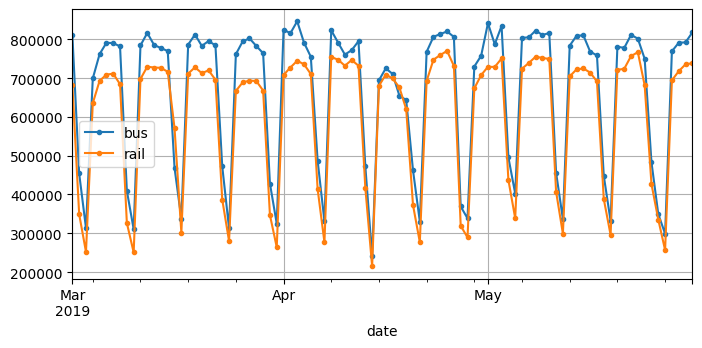

In [ ]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

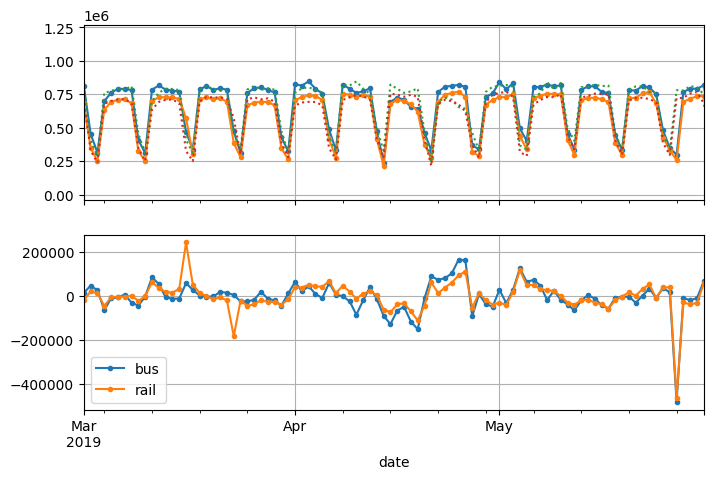

In [ ]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".") # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".") # 7-day difference time series
plt.show()

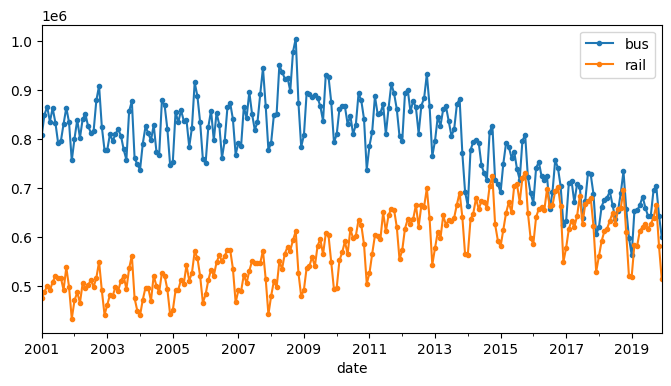

In [ ]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()

# rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
# rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, series, window_len):
    self.series = series
    self.window_len = window_len

  def __len__(self):
    return len(self.series) - self.window_len

  def __getitem__(self, idx):
    if idx >= len(self.series):
      raise IndexError("Index out of range")
    end = idx + self.window_len
    window = self.series[idx:end]
    # target = self.series[end] # predict next day
    target = self.series[end:end+14] # predict next 14 days
    return window, target


In [ ]:
import torch

rail_train = torch.FloatTensor(df[["rail", "bus"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail", "bus"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail", "bus"]]["2019-06":].values / 1e6)


window_len = 56
train_ds = TimeSeriesDataset(rail_train, window_len)
valid_ds = TimeSeriesDataset(rail_valid, window_len)
test_ds = TimeSeriesDataset(rail_test, window_len)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=1)
valid_dl = DataLoader(valid_ds, batch_size=1)

sample_X, sample_y = next(iter(train_dl))
print("batch", sample_X.shape[0], "window_lenght", sample_X.shape[1], "dimensionality", sample_X.shape[2])
print(sample_y.shape)

batch 32 window_lenght 56 dimensionality 2
torch.Size([32, 14, 2])


In [ ]:
import torch.nn as nn
import torchmetrics

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(56, 1)
)

if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

torch.manual_seed(42)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)
criterion = nn.HuberLoss()
n_epochs = 20

model.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)
    # Forward
    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()
    # Backward
    loss.backward() # calcular gradiente de parametros
    # GDS
    optimizer.step() # actualizar parametros
    optimizer.zero_grad() # reset the gradients
    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())


# def eval_model(model, metric, device, test_dl):
#   metric.to(device)
#   model.eval()
#   with torch.no_grad():
#     for X_batch, y_batch in test_dl:
#       X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#       y_pred = model(X_batch)
#       metric.update(y_pred, y_batch)

#   return metric.compute()
# metric = torchmetrics.MeanAbsoluteError().to(device)
# print(eval_model(model, metric, device, test_dl))


# metric = 0
# model.eval()
# with torch.no_grad():
#   for X_batch, y_batch in test_dl:
#     X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#     y_pred = model(X_batch)
#     metric += (y_pred - y_batch).abs().mean()
# print(metric)


train total loss: 1.5499107707291842
tensor(0.2391)
train total loss: 0.43561074580065906
tensor(0.1308)
train total loss: 0.2851527954917401
tensor(0.1021)
train total loss: 0.20558034884743392
tensor(0.0821)
train total loss: 0.16933975485153496
tensor(0.0724)
train total loss: 0.15394436137285084
tensor(0.0666)
train total loss: 0.14836001012008637
tensor(0.0652)
train total loss: 0.13974204834084958
tensor(0.0617)
train total loss: 0.13342265808023512
tensor(0.0594)
train total loss: 0.12960652663605288
tensor(0.0583)
train total loss: 0.12955265503842384
tensor(0.0590)
train total loss: 0.12764627288561314
tensor(0.0575)
train total loss: 0.12489460071083158
tensor(0.0565)
train total loss: 0.12287414073944092
tensor(0.0558)
train total loss: 0.12661727843806148
tensor(0.0554)
train total loss: 0.12076142197474837
tensor(0.0549)
train total loss: 0.1160477259545587
tensor(0.0545)
train total loss: 0.12107856094371527
tensor(0.0556)
train total loss: 0.1153197058592923
tensor(0.054

In [ ]:
class SimpleRnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.memory_cell = nn.Sequential(
      nn.Linear(input_size + hidden_size, hidden_size),
      nn.Tanh()
    )
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    batch_size, window_length, dimensionality = X.shape
    X_time_first = X.transpose(0, 1)
    H = torch.zeros(batch_size, self.hidden_size, device=X.device)
    for X_t in X_time_first:
      XH = torch.cat((X_t, H), dim=1)
      H = self.memory_cell(XH)
    return self.output(H)

torch.manual_seed(42)

model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
criterion = nn.HuberLoss()
n_epochs = 20

model.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())


train total loss: 3.3175352942198515
tensor(0.3852, device='cuda:0')
train total loss: 0.5505072674714029
tensor(0.1414, device='cuda:0')
train total loss: 0.5003649005666375
tensor(0.1560, device='cuda:0')
train total loss: 0.4953844752162695
tensor(0.1546, device='cuda:0')
train total loss: 0.4953432893380523
tensor(0.1518, device='cuda:0')
train total loss: 0.49036801792681217
tensor(0.1545, device='cuda:0')
train total loss: 0.48567811120301485
tensor(0.1508, device='cuda:0')
train total loss: 0.48192901723086834
tensor(0.1512, device='cuda:0')
train total loss: 0.47849313681945205
tensor(0.1534, device='cuda:0')
train total loss: 0.4807289047166705
tensor(0.1501, device='cuda:0')
train total loss: 0.4748033005744219
tensor(0.1483, device='cuda:0')
train total loss: 0.4711783789098263
tensor(0.1503, device='cuda:0')
train total loss: 0.4708966948091984
tensor(0.1487, device='cuda:0')
train total loss: 0.4664492206647992
tensor(0.1500, device='cuda:0')
train total loss: 0.4658880149

In [ ]:
"""multivariative seq2seq"""

import torch
import torch.nn as nn
import torchmetrics

class MSeq2SeqRnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.memory_cell = nn.Sequential(
      nn.Linear(input_size + hidden_size, hidden_size),
      nn.Tanh()
    )
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    batch_size, window_length, dimensionality = X.shape
    X_time_first = X.transpose(0, 1)
    H = torch.zeros(batch_size, self.hidden_size, device=X.device)
    for X_t in X_time_first:
      XH = torch.cat((X_t, H), dim=1)
      H = self.memory_cell(XH)
    return self.output(H)

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

model2 = MSeq2SeqRnnModel(input_size=2, hidden_size=32, output_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)
criterion = nn.HuberLoss()
n_epochs = 20

model2.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())


RuntimeError: stack expects each tensor to be equal size, but got [14, 2] at entry 0 and [11, 2] at entry 17

In [ ]:
class RnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])



model = RnnModel(input_size=1, hidden_size=32, output_size=1)

optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)
criterion = nn.HuberLoss()
n_epochs = 20


model.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())

train total loss: 3.649799194186926
tensor(0.3648, device='cuda:0')
train total loss: 0.561589265242219
tensor(0.1607, device='cuda:0')
train total loss: 0.5190901076421142
tensor(0.1571, device='cuda:0')
train total loss: 0.5163917448371649
tensor(0.1586, device='cuda:0')
train total loss: 0.512270743958652
tensor(0.1551, device='cuda:0')
train total loss: 0.512402968481183
tensor(0.1568, device='cuda:0')
train total loss: 0.5077985050156713
tensor(0.1559, device='cuda:0')
train total loss: 0.5014065448194742
tensor(0.1560, device='cuda:0')
train total loss: 0.5023634252138436
tensor(0.1547, device='cuda:0')
train total loss: 0.4966002982109785
tensor(0.1546, device='cuda:0')
train total loss: 0.49199120979756117
tensor(0.1544, device='cuda:0')
train total loss: 0.4907881189137697
tensor(0.1541, device='cuda:0')
train total loss: 0.4872438898310065
tensor(0.1510, device='cuda:0')
train total loss: 0.48771103098988533
tensor(0.1542, device='cuda:0')
train total loss: 0.4844976551830768

In [ ]:
class DeepRnnModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers=3, batch_first=True)
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])



model = DeepRnnModel(input_size=1, hidden_size=32, output_size=1)


optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)
criterion = nn.HuberLoss()
n_epochs = 20

model.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())

train total loss: 1.2147344872355461
tensor(0.2058)
train total loss: 0.3635899154469371
tensor(0.1230)
train total loss: 0.17770242725964636
tensor(0.0740)
train total loss: 0.16721366718411446
tensor(0.0716)
train total loss: 0.15386932506226003
tensor(0.0707)
train total loss: 0.1518638429697603
tensor(0.0677)
train total loss: 0.13625528290867805
tensor(0.0632)
train total loss: 0.13712271756958216
tensor(0.0647)
train total loss: 0.14110408874694258
tensor(0.0666)
train total loss: 0.12595091888215393
tensor(0.0607)
train total loss: 0.12399797048419714
tensor(0.0597)
train total loss: 0.12931990576907992
tensor(0.0606)
train total loss: 0.11764656624291092
tensor(0.0561)
train total loss: 0.1193982299300842
tensor(0.0563)
train total loss: 0.10252907325048
tensor(0.0497)
train total loss: 0.12068592722062021
tensor(0.0590)
train total loss: 0.10232776310294867
tensor(0.0494)
train total loss: 0.10400257055880502
tensor(0.0510)
train total loss: 0.09976821957388893
tensor(0.0494)


In [ ]:
class DeepGRUModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.GRU(input_size, hidden_size, num_layers=3, batch_first=True)
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    outputs, last_state = self.rnn(X)
    return self.output(outputs[:, -1])


model = DeepGRUModel(input_size=1, hidden_size=32, output_size=1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)
criterion = nn.HuberLoss()
n_epochs = 20

model.to(device)
for epoch in range(n_epochs):
  metric.reset()
  model.train()
  total_loss = 0
  for X, y in train_dl:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
      metric.update(y_pred, y)

  print("train total loss: %s" %(total_loss))
  print(metric.compute())

train total loss: 1.678861859254539
tensor(0.2334)
train total loss: 0.5879945117048919
tensor(0.1652)
train total loss: 0.5483489204198122
tensor(0.1612)
train total loss: 0.5488671008497477
tensor(0.1588)
train total loss: 0.5533542651683092
tensor(0.1613)
train total loss: 0.5543180843815207
tensor(0.1582)
train total loss: 0.5368745923042297
tensor(0.1583)
train total loss: 0.5517912106588483
tensor(0.1567)
train total loss: 0.5257940944284201
tensor(0.1569)
train total loss: 0.42886188300326467
tensor(0.1401)
train total loss: 0.27240226534195244
tensor(0.1022)
train total loss: 0.1299243422690779
tensor(0.0600)
train total loss: 0.1236437656916678
tensor(0.0582)
train total loss: 0.11729119985830039
tensor(0.0557)
train total loss: 0.11594503320520744
tensor(0.0528)
train total loss: 0.10662043100455776
tensor(0.0516)
train total loss: 0.10423599154455587
tensor(0.0518)
train total loss: 0.10461862053489313
tensor(0.0523)
train total loss: 0.10649823246058077
tensor(0.0519)
train

In [ ]:
class ForecastAheadDataset(TimeSeriesDataset):
  def __len__(self):
    return len(self.series) - self.window_len - 14 + 1
  def __getitem__(self, idx):
    end = idx + self.window_len # 1st index after window
    window = self.series[idx : end]
    target = self.series[end : end + 14, 0] # 0 = rail ridership
    return window, target

df_mulvar = df[["rail", "bus"]] / 1e6 # use both rail & bus series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1) # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)

mulvar_train = torch.FloatTensor(df_mulvar["2016-01":"2018-12"].values / 1e6)
mulvar_valid = torch.FloatTensor(df_mulvar["2019-01":"2019-05"].values / 1e6)
mulvar_test = torch.FloatTensor(df_mulvar["2019-06":].values / 1e6)

window_len = 56
ahead_train_set = ForecastAheadDataset(mulvar_train, window_len)
ahead_train_loader = DataLoader(ahead_train_set, batch_size=32, shuffle=True)

sample = next(iter(ahead_train_loader))
print(len(sample), sample[0].shape, sample[1].shape)

In [ ]:
import torch.nn as nn

class MultiheadAttention(nn.Module):
  def __init__(self, num_heads, embed_dim, dropout=0.1):
    super().__init__()
    self.h = num_heads
    self.d = embed_dim // num_heads # embed_dim = h x d
    self.q_proj = nn.Linear(embed_dim, embed_dim)
    self.k_proj = nn.Linear(embed_dim, embed_dim)
    self.v_proj = nn.Linear(embed_dim, embed_dim)
    self.out_proj = nn.Linear(embed_dim, embed_dim)
    self.dropout = nn.Dropout(dropout)

  def split_heads(self, X):
    return X.view(X.size(0), X.size(1), self.h, self.d).transpose(1, 2) # -> (B, h, L, d), L = max length of input sequence

  def forward(self, query, key, value):
    q = self.split_heads(self.q_proj(query)) # (B, h, Lq, d)
    k = self.split_heads(self.k_proj(key)) # (B, h, Lk, d)
    v = self.split_heads(self.v_proj(value)) # (B, h, Lv, d) with Lv=Lk
    scores = q @ k.transpose(2, 3) / self.d**0.5 # (B, h, Lq, d) x (B, h, d, Lk) -> (B, h, Lq, Lk)
    weights = scores.softmax(dim=-1) # (B, h, Lq, Lk)
    Z = self.dropout(weights) @ v # (B, h, Lq, d)
    Z = Z.transpose(1, 2) # (B, Lq, h, d)
    Z = Z.reshape(Z.size(0), Z.size(1), self.h * self.d) # (B, Lq, h × d)
    return (self.out_proj(Z), weights) # (B, Lq, h × d)


# Pytorch module has same arguments and outputs
# mha = nn.MultiheadAttention(batch_first=True, need_weights=True, is_causal=True)

TypeError: MultiheadAttention.__init__() got an unexpected keyword argument 'need_weights'

# Shakespeare

In [ ]:
from pathlib import Path
import urllib.request

def download_shakespeare_text():
  path = Path("datasets/shakespeare/shakespeare.txt")
  if not path.is_file():
    path.parent.mkdir(parents=True, exist_ok=True)
    url = "https://homl.info/shakespeare"
    urllib.request.urlretrieve(url, path)
  return path.read_text()

shakespeare_text = download_shakespeare_text()

In [ ]:
vocab = sorted(set(shakespeare_text.lower())) # cada caracter/letra es un token
print(len(vocab))
"".join(vocab)

39


"\n !$&',-.3:;?abcdefghijklmnopqrstuvwxyz"

In [ ]:
char_to_idx = {char:idx for idx, char in enumerate(vocab)}
idx_to_char = {idx:char for idx, char in enumerate(vocab)}


import torch

def encode_text(text):
  return torch.tensor([char_to_idx[char] for char in text.lower()])

def decode_text(char_ids):
  return "".join([idx_to_char[id.item()] for id in char_ids])

print(encode_text("hello world"))
print(decode_text(encode_text("hello world")))

tensor([20, 17, 24, 24, 27,  1, 35, 27, 30, 24, 16])
hello world


In [ ]:
from torch.utils.data import Dataset, DataLoader

class ShakespeareDataset(Dataset):
  def __init__(self, text, window_len):
    self.encoded_text = encode_text(text)
    self.window_len = window_len

  def __len__(self):
    return len(self.encoded_text) - self.window_len

  def __getitem__(self, idx):
    if idx >= len(self):
      raise IndexError("Index out of range")
    end = idx + self.window_len
    window = self.encoded_text[idx : end]
    target = self.encoded_text[idx + 1 : end + 1]
    return window, target


window_length = 50
batch_size = 512 # reduce if your GPU cannot handle such a large batch size
train_set = ShakespeareDataset(shakespeare_text[:1_000_000], window_length)
valid_set = ShakespeareDataset(shakespeare_text[1_000_000:1_060_000], window_length)
test_set = ShakespeareDataset(shakespeare_text[1_060_000:], window_length)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

next(iter(train_set))[0].shape

torch.Size([50])

In [ ]:
import torch.nn as nn
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

class ShakespeareModel(nn.Module):
  def __init__(self, len_vocab, hidden_size=128, emb_size=10, n_layers=2, dropout=0.1):
    super().__init__()
    self.embedding = nn.Embedding(len_vocab, emb_size)
    self.gru = nn.GRU(emb_size, hidden_size, n_layers, dropout=dropout, batch_first=True)
    self.output = nn.Linear(hidden_size, len_vocab)
  def forward(self, X):
    embeddings = self.embedding(X)
    outputs, _states = self.gru(embeddings)
    return self.output(outputs).permute(0, 2, 1)

model = ShakespeareModel(len(vocab))
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) #, momentum=0.9, nesterov=True
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
n_epochs = 20

for epoch in range(n_epochs):
  model.train()
  total_loss = 0
  for X, y in train_loader:
    X = X.to(device)
    y = y.to(device)

    # reset gradients
    optimizer.zero_grad()
    # forward
    y_pred = model(X)
    loss = criterion(y_pred, y)
    # backward
    loss.backward()
    # gradient descent step
    optimizer.step()
    # scheduler.step()

    total_loss += loss.item()
  print("epoca:%s, last loss:" %(epoch), loss)

print("train total loss: %s" %(total_loss))

epoca:0, last loss: tensor(3.0483, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:1, last loss: tensor(2.9705, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:2, last loss: tensor(2.8750, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:3, last loss: tensor(2.8317, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:4, last loss: tensor(2.7290, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:5, last loss: tensor(2.6256, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:6, last loss: tensor(2.6443, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:7, last loss: tensor(2.5532, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:8, last loss: tensor(2.5197, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:9, last loss: tensor(2.4911, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:10, last loss: tensor(2.4357, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:11, last loss: tensor(2.3813, device='cuda:0', grad_fn=<NllLoss2DBackward0>)
epoca:12, last

In [ ]:

model.eval() # don't forget to switch the model to evaluation mode!
text = "To be or not to b"
encoded_text = encode_text(text).unsqueeze(dim=0).to(device)

with torch.no_grad():
  Y_logits = model(encoded_text)
  predicted_char_id = Y_logits[0, :, -1].argmax().item()
  predicted_char = idx_to_char[predicted_char_id] # correctly predicts "e"

predicted_char

'e'

In [ ]:
import torch.nn.functional as F

def next_char(model, text, temperature=1):
  encoded_text = encode_text(text).unsqueeze(dim=0).to(device)
  with torch.no_grad():
    Y_logits = model(encoded_text)
    Y_probas = F.softmax(Y_logits[0, :, -1] / temperature, dim=-1)
    predicted_char_id = torch.multinomial(Y_probas, num_samples=1).item()
  return idx_to_char[predicted_char_id]

def extend_text(model, text, n_chars=100, temperature=0.4):
  for _ in range(n_chars):
    text += next_char(model, text, temperature)
  return text

extend_text(model, text)

'To be or not to be the will the here sing that it you sore the the mere for the the the seent the seed and the the th'

In [ ]:
encoded_text = encode_text("Hola mund").unsqueeze(dim=0).to(device)
print(encoded_text)
with torch.no_grad():
  Y_logits = model(encoded_text)
print(Y_logits.shape, len(vocab))

tensor([[20, 27, 24, 13,  1, 25, 33, 26, 16]], device='cuda:0')
torch.Size([1, 39, 9]) 39


# IMDB

In [ ]:
from datasets import load_dataset

imdb_dataset = load_dataset("stanfordnlp/imdb")
split = imdb_dataset["train"].train_test_split(train_size=0.8, seed=42)
imdb_train, imdb_val = split["train"], split["test"]
imdb_test = imdb_dataset["test"]

imdb_train[1]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

{'text': "'The Rookie' was a wonderful movie about the second chances life holds for us and also puts an emotional thought over the audience, making them realize that your dreams can come true. If you loved 'Remember the Titans', 'The Rookie' is the movie for you!! It's the feel good movie of the year and it is the perfect movie for all ages. 'The Rookie' hits a major home run!",
 'label': 1}

In [ ]:
len(imdb_train), len(imdb_test), len(imdb_val)

(20000, 25000, 5000)

In [ ]:
import tokenizers

bpe_model = tokenizers.models.WordPiece(unk_token="<unk>")
bpe_tokenizer = tokenizers.Tokenizer(bpe_model)

bpe_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()

train_reviews = [review["text"].lower() for review in imdb_train]
bpe_trainer = tokenizers.trainers.WordPieceTrainer(vocab_size=1000, special_tokens=["<pad>", "<unk>"])

bpe_tokenizer.train_from_iterator(train_reviews, bpe_trainer)

bpe_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
bpe_tokenizer.enable_truncation(max_length=500)

In [ ]:
encoding = bpe_tokenizer.encode(imdb_train[1]["text"])
print(encoding)

print(encoding.ids[:20])
print(encoding.tokens[:20])
print(bpe_tokenizer.decode(encoding.ids[:20]))
print(encoding.attention_mask[:20])

Encoding(num_tokens=114, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
[10, 1, 1, 10, 311, 42, 895, 522, 331, 431, 252, 870, 526, 333, 664, 137, 655, 864, 327, 137]
["'", '<unk>', '<unk>', "'", 'was', 'a', 'wonder', '##ful', 'movie', 'about', 'the', 'sec', '##ond', 'ch', '##ance', '##s', 'life', 'ho', '##ld', '##s']
' ' was a wonder ##ful movie about the sec ##ond ch ##ance ##s life ho ##ld ##s
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
import torch
from torch.utils.data import DataLoader

def collate_fcn(batch, tokenizer=bpe_tokenizer):
  reviews = [review["text"].lower() for review in batch]
  labels = [review["label"] for review in batch]

  encodings = tokenizer.encode_batch(reviews)

  token_ids = torch.tensor([encoding.ids for encoding in encodings])
  attention_mask = torch.tensor([encoding.attention_mask for encoding in encodings])
  labels = torch.tensor(labels, dtype=torch.float32)

  return token_ids, attention_mask, labels

imdb_train_dl = DataLoader(imdb_train, collate_fn=collate_fcn, batch_size=32, shuffle=True)
imdb_test_dl = DataLoader(imdb_test, collate_fn=collate_fcn, batch_size=32)
imdb_val_dl = DataLoader(imdb_val, collate_fn=collate_fcn, batch_size=32)

In [ ]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class mnt_imdb(nn.Module):
  def __init__(self, vocab_size=1000, embedding_size=128, hidden_size=64, num_layers=2, dropout=0.2, pad_id=0):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=pad_id)
    self.gru = nn.GRU(embedding_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)
    self.output = nn.Linear(2*hidden_size, 1)

  def forward(self, token_ids, attention_mask):
    embedds = self.embed(token_ids)
    # _outputs, hidden_states = self.gru(embedds)
    # return self.output(hidden_states[-1]) # hidden_states porque s2v, no s2s
    lengths = attention_mask.sum(dim=1).to("cpu")
    packed = pack_padded_sequence(embedds, batch_first=True, lengths=lengths, enforce_sorted=False)
    _outputs, hidden_states = self.gru(packed)
    n_dims = self.output.in_features
    top_states = hidden_states[-2:].permute(1, 0, 2).reshape(-1, n_dims)
    return self.output(top_states)



device = "cuda" if torch.cuda.is_available() else "cpu"
model = mnt_imdb().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
n_epochs = 15

for epoch in range(n_epochs):
  model.train()
  total_loss = 0
  for tk_ids, att_mask, labels in imdb_train_dl:
    tk_ids, att_mask, labels = tk_ids.to(device), att_mask.to(device), labels.to(device)

    optimizer.zero_grad()

    logits = model(tk_ids, att_mask).squeeze(dim=1)
    loss = criterion(logits, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  print("Epoch:%s" %(epoch), total_loss)

Epoch:0 399.5302684903145
Epoch:1 264.82500137388706
Epoch:2 197.17749544978142
Epoch:3 159.63573575019836
Epoch:4 131.79294320754707
Epoch:5 101.2642051614821
Epoch:6 70.34698986727744
Epoch:7 53.181545389350504
Epoch:8 36.58299156697467
Epoch:9 27.332947295508347
Epoch:10 23.57301346154418
Epoch:11 24.85235891630873
Epoch:12 15.575055415305542
Epoch:13 14.4058534903088
Epoch:14 13.712754190015403


In [ ]:
metric = 0

model.eval()
with torch.no_grad():
  for tk_ids, att_mask, labels in imdb_test_dl:
      tk_ids, att_mask, labels = tk_ids.to(device), att_mask.to(device), labels.to(device)
      logits = model(tk_ids, att_mask).squeeze(1)
      preds = (logits > 0).long()
      metric += (preds == labels).float().mean().item()
metric /= len(imdb_test_dl)

metric

0.8522218670076727

# Translator

In [ ]:
from datasets import load_dataset

# imdb_dataset = load_dataset("imdb")
# split = imdb_dataset["train"].train_test_split(train_size=0.8, seed=42)
# imdb_train_set, imdb_valid_set = split["train"], split["test"]
# imdb_test_set = imdb_dataset["test"]

nmt_original_valid_set, nmt_test_set = load_dataset(
                                                    path="ageron/tatoeba_mt_train", name="eng-spa",
                                                    split=["validation", "test"]
                                                    )
split = nmt_original_valid_set.train_test_split(train_size=0.8, seed=42)
nmt_train_set, nmt_valid_set = split["train"], split["test"]

nmt_train_set[0]

In [ ]:
def train_eng_spa():
  for pair in nmt_train_set:
    yield pair["source_text"]
    yield pair["target_text"]

import tokenizers

max_length = 256
vocab_size = 10_000

nmt_tokenizer_model = tokenizers.models.BPE(unk_token="<unk>")
nmt_tokenizer = tokenizers.Tokenizer(nmt_tokenizer_model)
nmt_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
nmt_tokenizer.enable_truncation(max_length=max_length)
nmt_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()
nmt_tokenizer_trainer = tokenizers.trainers.BpeTrainer(
vocab_size=vocab_size, special_tokens=["<pad>", "<unk>", "<s>", "</s>"])
nmt_tokenizer.train_from_iterator(train_eng_spa(), nmt_tokenizer_trainer)

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

from collections import namedtuple

fields = ["src_token_ids", "src_mask", "tgt_token_ids", "tgt_mask"]
class NmtPair(namedtuple("NmtPairBase", fields)):
  def to(self, device):
    return NmtPair(self.src_token_ids.to(device), self.src_mask.to(device),self.tgt_token_ids.to(device), self.tgt_mask.to(device))


def nmt_collate_fn(batch):
  src_texts = [pair['source_text'] for pair in batch]
  tgt_texts = [f"<s> {pair['target_text']} </s>" for pair in batch]

  src_encodings = nmt_tokenizer.encode_batch(src_texts)
  tgt_encodings = nmt_tokenizer.encode_batch(tgt_texts)

  src_token_ids = torch.tensor([enc.ids for enc in src_encodings])
  tgt_token_ids = torch.tensor([enc.ids for enc in tgt_encodings])
  src_mask = torch.tensor([enc.attention_mask for enc in src_encodings])
  tgt_mask = torch.tensor([enc.attention_mask for enc in tgt_encodings])

  inputs = NmtPair(src_token_ids, src_mask, tgt_token_ids[:, :-1], tgt_mask[:, :-1])
  labels = tgt_token_ids[:, 1:]
  return inputs, labels


from torch.utils.data import DataLoader

batch_size = 32
nmt_train_loader = DataLoader(nmt_train_set, batch_size=batch_size, collate_fn=nmt_collate_fn, shuffle=True)
nmt_valid_loader = DataLoader(nmt_valid_set, batch_size=batch_size, collate_fn=nmt_collate_fn)
nmt_test_loader = DataLoader(nmt_test_set, batch_size=batch_size, collate_fn=nmt_collate_fn)

next(iter(nmt_train_loader))[0][1].shape

In [ ]:
import torch.nn as nn

class NmtEncDecModel(nn.Module):
  def __init__(self, vocab_size, embed_dim=512, pad_id=0, hidden_dim=512, n_layers=2):
    super().__init__()
    self.embeding = nn.Embedding(vocab_size, embed_dim)
    self.encoder = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True)
    self.decoder = nn. GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True)
    self.output = nn.Linear(hidden_dim, vocab_size)

  def forward(self, pair):
    src_embeddings = self.embed(pair.src_token_ids)
    tgt_embeddings = self.embed(pair.tgt_token_ids)
    src_lengths = pair.src_mask.sum(dim=1)
    src_packed = pack_padded_sequence(src_embeddings, lengths=src_lengths.cpu(), batch_first=True, enforce_sorted=False)
    _, hidden_states = self.encoder(src_packed)
    outputs, _ = self.decoder(tgt_embeddings, hidden_states)
    return self.output(outputs).permute(0, 2, 1)

vocab_size = nmt_tokenizer.get_vocab_size()
model = NmtEncDecModel(vocab_size)

n_epochs = 5
optimizer = torch.optim.SGD(model.parametrs(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.to(device)
for epoch in range(n_epochs):
  model.train()
  total_loss = 0
  for X, y in nmt_train_loader:
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()

    y_pred = model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    # print("epoca:%s, total loss:" %(epoch), total_loss)


metric = torchmetrics
metric.to(device)

model.eval()
with torch.no_grad():
  for X_batch, y_batch in nmt_test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    y_pred = model(X_batch)
    metric.update(y_pred, y_batch)



# Attention

In [ ]:
import torch.nn as nn

class MultiheadAttention(nn.Module):
  def __init__(self, num_heads, embed_dim, dropout=0.1):
    super().__init__()
    self.h = num_heads
    self.d = embed_dim // num_heads # embed_dim = h x d
    self.q_proj = nn.Linear(embed_dim, embed_dim)
    self.k_proj = nn.Linear(embed_dim, embed_dim)
    self.v_proj = nn.Linear(embed_dim, embed_dim)
    self.out_proj = nn.Linear(embed_dim, embed_dim)
    self.dropout = nn.Dropout(dropout)

  def split_heads(self, X):
    return X.view(X.size(0), X.size(1), self.h, self.d).transpose(1, 2) # -> (B, h, L, d), L = max length of input sequence

  def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
    q = self.split_heads(self.q_proj(query)) # (B, h, Lq, d)
    k = self.split_heads(self.k_proj(key)) # (B, h, Lk, d) with dq = dk
    v = self.split_heads(self.v_proj(value)) # (B, h, Lv, d) with Lv=Lk
    scores = q @ k.transpose(2, 3) / self.d**0.5 # (B, h, Lq, d) x (B, h, d, Lk) -> (B, h, Lq, Lk)
    if attn_mask is not None: # mask padding tokens and future tokens, decoder's mha is causal
      scores = scores.masked_filled(attn_mask, -torch.inf) # (B, h, Lq, Lk)
    if key_padding_mask is not None: # if the key contains padding tokens, ignore them
      mask = key_padding_mask.unsqueeze(1).unsqueeze(2) # # (B, 1, 1, Lk)
      scores = scores.masked_fill(mask, -torch.inf) # (B, h, Lq, Lk)
    weights = scores.softmax(dim=-1) # (B, h, Lq, Lk)
    Z = self.dropout(weights) @ v # (B, h, Lq, d)
    Z = Z.transpose(1, 2) # (B, Lq, h, d)
    Z = Z.reshape(Z.size(0), Z.size(1), self.h * self.d) # (B, Lq, h × d)
    return (self.out_proj(Z), weights) # (B, Lq, h × d)


# Pytorch module has same arguments (even more) and outputs
mha = nn.MultiheadAttention(batch_first=True, need_weights=False, is_causal=True)

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
    super().__init__()
    self.self_attn = MultiheadAttention(d_model, nhead, dropout)
    self.linear1 = nn.Linear(d_model, dim_feedforward)
    self.linear2 = nn.Linear(dim_feedforward, d_model)
    self.dropout = nn.Dropout(dropout)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)

  def forward(self, src, src_mask=None, src_key_padding_mask=None):
    attn, _ = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)
    Z = self.norm1(src + self.dropout(attn))
    ff = self.dropout(self.linear2(self.dropout(self.linear1(Z).relu())))
    return self.norm2(Z + ff)


class TransformerDecoderLayer(nn.Module):
  def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
    super().__init__()
    self.self_attn = MultiheadAttention(d_model, nhead, dropout)
    self.multihead_attn = MultiheadAttention(d_model, nhead, dropout)
    self.linear1 = nn.Linear(d_model, dim_feedforward)
    self.linear2 = nn.Linear(dim_feedforward, d_model)
    self.dropout = nn.Dropout(dropout)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)

  def forward(self, tgt, memory, tgt_mask=None, memory_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
    attn1, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
    Z = self.norm1(tgt + self.dropout(attn1))
    attn2, _ = self.multihead_attn(Z, memory, memory, attn_mask=memory_mask, key_padding_mask=memory_key_padding_mask)
    Z = self.norm2(Z + self.dropout(attn2))
    ff = self.dropout(self.linear2(self.dropout(self.linear1(Z).relu())))
    return self.norm3(Z + ff)

# Pytorch module has same arguments and outputs
import torch.nn.functional as F

encoder = nn.TransformerEncoderLayer(batch_first=True, is_causal=False, activation=F.relu)
decoder = nn.TransformerDecoderLayer(batch_first=True, is_causal=True, activation=F.relu)
# nn.TransformerEncoder
# nn.TransformerDecoder
# nn.Transformer

### Dataset

In [ ]:
from datasets import load_dataset

# imdb_dataset = load_dataset("imdb")
# split = imdb_dataset["train"].train_test_split(train_size=0.8, seed=42)
# imdb_train_set, imdb_valid_set = split["train"], split["test"]
# imdb_test_set = imdb_dataset["test"]

nmt_original_valid_set, nmt_test_set = load_dataset(
                                                    path="ageron/tatoeba_mt_train", name="eng-spa",
                                                    split=["validation", "test"]
                                                    )
split = nmt_original_valid_set.train_test_split(train_size=0.8, seed=42)
nmt_train_set, nmt_valid_set = split["train"], split["test"]

nmt_train_set[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

eng-spa/validation-00000-of-00001.parque(…):   0%|          | 0.00/7.85M [00:00<?, ?B/s]

eng-spa/test-00000-of-00001.parquet:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/197299 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24514 [00:00<?, ? examples/s]

{'source_text': 'Tom tried to break up the fight.',
 'target_text': 'Tom trató de disolver la pelea.',
 'source_lang': 'eng',
 'target_lang': 'spa'}

In [ ]:
def train_eng_spa():
  for pair in nmt_train_set:
    yield pair["source_text"]
    yield pair["target_text"]

import tokenizers

max_length = 256
vocab_size = 10_000

nmt_tokenizer_model = tokenizers.models.BPE(unk_token="<unk>")
nmt_tokenizer = tokenizers.Tokenizer(nmt_tokenizer_model)
nmt_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
nmt_tokenizer.enable_truncation(max_length=max_length)
nmt_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()
nmt_tokenizer_trainer = tokenizers.trainers.BpeTrainer(
vocab_size=vocab_size, special_tokens=["<pad>", "<unk>", "<s>", "</s>"])
nmt_tokenizer.train_from_iterator(train_eng_spa(), nmt_tokenizer_trainer)

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

from collections import namedtuple

fields = ["src_token_ids", "src_mask", "tgt_token_ids", "tgt_mask"]
class NmtPair(namedtuple("NmtPairBase", fields)):
  def to(self, device):
    return NmtPair(self.src_token_ids.to(device), self.src_mask.to(device),self.tgt_token_ids.to(device), self.tgt_mask.to(device))


def nmt_collate_fn(batch):
  src_texts = [pair['source_text'] for pair in batch]
  tgt_texts = [f"<s> {pair['target_text']} </s>" for pair in batch]

  src_encodings = nmt_tokenizer.encode_batch(src_texts)
  tgt_encodings = nmt_tokenizer.encode_batch(tgt_texts)

  src_token_ids = torch.tensor([enc.ids for enc in src_encodings])
  tgt_token_ids = torch.tensor([enc.ids for enc in tgt_encodings])
  src_mask = torch.tensor([enc.attention_mask for enc in src_encodings])
  tgt_mask = torch.tensor([enc.attention_mask for enc in tgt_encodings])

  inputs = NmtPair(src_token_ids, src_mask, tgt_token_ids[:, :-1], tgt_mask[:, :-1])
  labels = tgt_token_ids[:, 1:]
  return inputs, labels


from torch.utils.data import DataLoader

batch_size = 32
nmt_train_loader = DataLoader(nmt_train_set, batch_size=batch_size, collate_fn=nmt_collate_fn, shuffle=True)
nmt_valid_loader = DataLoader(nmt_valid_set, batch_size=batch_size, collate_fn=nmt_collate_fn)
nmt_test_loader = DataLoader(nmt_test_set, batch_size=batch_size, collate_fn=nmt_collate_fn)

next(iter(nmt_train_loader))[0][1].shape

torch.Size([32, 84])

### Train model

In [ ]:
import torch.nn as nn

class PositionalEmbedding(nn.Module):
  def __init__(self, max_length, embed_dim, dropout=0.1):
    super().__init__()
    self.pos_emdedd = nn.Parameter(torch.randn(max_length, embed_dim)*0.02)
    self.dropout = nn.Dropout(dropout)

  def forward(self, X):
    return self.dropout(X+self.pos_emdedd[:X.size(1)])

In [ ]:
class NmtTransformer(nn.Module):
  def __init__(self, vocab_size, max_length, embed_dim=128, pad_id=0, num_heads=4, num_layers=2, dropout=0.1):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
    self.pos_embed = PositionalEmbedding(max_length, embed_dim, dropout)
    self.transformer = nn.Transformer(embed_dim, num_heads, num_encoder_layers=num_layers, num_decoder_layers=num_layers, batch_first=True)
    self.output = nn.Linear(embed_dim, vocab_size)

  def forward(self, pair):
    src_embeds = self.pos_embed(self.embed(pair.src_token_ids))
    tgt_embeds = self.pos_embed(self.embed(pair.tgt_token_ids))
    src_pad_mask = ~pair.src_mask.bool()
    tgt_pad_mask = ~pair.tgt_mask.bool()

    size = [pair.tgt_token_ids.size(1)] * 2
    full_mask = torch.full(size, True, device=tgt_pad_mask.device)
    causal_mask = torch.triu(full_mask, diagonal=1)

    out_decoder = self.transformer(src_embeds,
                                   tgt_embeds,
                                   src_key_padding_mask=src_pad_mask,
                                   memory_key_padding_mask=src_pad_mask,
                                   tgt_mask=causal_mask,
                                   tgt_key_padding_mask=tgt_pad_mask,
                                   tgt_is_causal=True)
    return self.output(out_decoder).permute(0, 2, 1)

vocab_size = nmt_tokenizer.get_vocab_size()
model = NmtTransformer(vocab_size, max_length=500)

n_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.to(device)
for epoch in range(n_epochs):
  model.train()
  total_loss = 0
  for X, y in nmt_train_loader:
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()

    y_pred = model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  print("epoca:%s, total loss:" %(epoch), total_loss)


epoca:0, total loss: 17078.51089054346
epoca:1, total loss: 14648.851491808891
epoca:2, total loss: 13925.274787545204
epoca:3, total loss: 13624.71417415142
epoca:4, total loss: 13368.47540858388
epoca:5, total loss: 13148.777156472206
epoca:6, total loss: 13028.418418973684
epoca:7, total loss: 12879.130483835936
epoca:8, total loss: 12771.270623743534
epoca:9, total loss: 12691.204036980867


# GPT (decoder-only)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", dtype="auto")

model

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
def generate(model, tokenizer, prompt, max_new_tokens=100, **generate_kwargs):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
  outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id, do_sample=True, **generate_kwargs)
  return tokenizer.decode(outputs[0], skip_special_tokens=True)

prompt = "It eternally wounds, flies fast, and kills"
generate(model, tokenizer, prompt)

"It eternally wounds, flies fast, and kills.\n\nDreadless by nature, he lives in a place far away from the city, but he has an interesting idea: a way out.\n\nWhen John O'Neill returns from his vacation in England, he encounters a young man named William O'Neill. (He had not seen or heard of Peter O'Neill, even though he had seen him often). He is convinced that William is the one who would help him. To persuade William to save him from an enemy,"

In [ ]:
import torch

torch.manual_seed(42)
generate(model, tokenizer, prompt, do_sample=True)

'There was a time for you to come to earth, but now it is time for me to return to my human form with my son." (Genesis 14:21–52) That was also how the bible describes him. Why? Because there is nothing here where Jesus came to leave the world. In Genesis 11:16–17 God says: "We will come before you, the ones who have received us." He knows that because there is no room where there are no other human beings, we have all'

## Chat Bot - Prompt Engineering

In [ ]:
bob_introduction = """Bob is an amazing chatbot. It knows everything and it's incredibly helpful."""

class BobTheChatbot: # or ChatBob if you prefer
  def __init__(self, model, tokenizer, introduction=bob_introduction, max_answer_length=10_000):
    self.model = model
    self.tokenizer = tokenizer
    self.context = introduction
    self.max_answer_length = max_answer_length

  def chat(self, prompt):
    self.context += "\nMe: " + prompt + "\nBob:"
    context = self.context
    start_index = len(context)
    while True:
      extended = generate(self.model, self.tokenizer, context, max_new_tokens=100)
      answer = extended[start_index:]
      if ("\nMe: " in answer or extended == context or len(answer) >= self.max_answer_length):
        break
      context = extended
    answer = answer.split("\nMe: ")[0]
    # print([self.context], [context], [answer])
    self.context += answer
    return answer.strip()

In [ ]:

bob = BobTheChatbot(model, tokenizer)
bob.chat("List some places I should visit in Paris.")

["Bob is an amazing chatbot. It knows everything and it's incredibly helpful.\nMe: List some places I should visit in Paris.\nBob:"] ["Bob is an amazing chatbot. It knows everything and it's incredibly helpful.\nMe: List some places I should visit in Paris.\nBob:"] [" I don't really know where to start. Where do you think you're going to go?"]


"I don't really know where to start. Where do you think you're going to go?"

In [ ]:
bob.chat("Maybe some museum.")

["Bob is an amazing chatbot. It knows everything and it's incredibly helpful.\nMe: List some places I should visit in Paris.\nBob: I don't really know where to start. Where do you think you're going to go?\nMe: Maybe some museum.\nBob:"] ["Bob is an amazing chatbot. It knows everything and it's incredibly helpful.\nMe: List some places I should visit in Paris.\nBob: I don't really know where to start. Where do you think you're going to go?\nMe: Maybe some museum.\nBob:"] [' Nice and easy thing. Let me walk you back.']


'Nice and easy thing. Let me walk you back.'

# BERT (encoder-only)

In [ ]:
"Fine-tuning model BERT on wikipedia dataset using MLM as self-supervised pretraining task"

from transformers import BertConfig, BertTokenizerFast, BertForMaskedLM

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

config = BertConfig(vocab_size = bert_tokenizer.vocab_size,
                    hidden_size = 128,
                    num_hidden_layers = 2,
                    num_attention_heads = 4,
                    intermediate_size = 512,
                    max_position_embeddings = 128
                    )

bert = BertForMaskedLM(config) # mlm, Masked Language Model

print(bert_tokenizer.vocab_size)

bert

# El módulo BertOnlyMLMHead se encarga de proyectar las representaciones ocultas del modelo (de dimensión 128) de vuelta al tamaño del vocabulario (30,522 tokens) para predecir las palabras enmascaradas

30522


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(128, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_aff

In [ ]:
bert_tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [ ]:
from datasets import load_dataset

mlm_dataset_raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")

def tokenize(example, tokenizer=bert_tokenizer):
  return tokenizer(example["text"], truncation=True, max_length=128, padding="max_length")

mlm_dataset = mlm_dataset_raw.map(tokenize, batched=True)

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

In [ ]:
print(mlm_dataset_raw)

mlm_dataset_raw[3500]['text']

Dataset({
    features: ['text'],
    num_rows: 36718
})


" Nathan spent all of 2003 with the Giants in the bullpen after marrying Lisa Lemoncelli , his girlfriend of five years , in November 2002 . This was a breakout year for Nathan , starting the season with 23 scoreless innings en route to a 12 – 4 record in his first full year as a reliever . His 78 appearances put him high on the list of most @-@ used pitchers for the season as one of the best setup men in the NL , allowing no runs in 15 appearances from July 18 to August 20 . His 12 wins in relief led the majors . The Giants won the National League West by 151 ⁄ 2 games and drew the Florida Marlins , the National League 's wild card winner , in the NLDS . Nathan was hit hard in that series , blowing his only save opportunity . His team fared no better , winning Game 1 behind Jason Schmidt 's complete game shutout before dropping the next three . \n"

In [ ]:
mlm_dataset

Dataset({
    features: ['text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36718
})

In [ ]:
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorForLanguageModeling

args = TrainingArguments(output_dir = "./eduardo_bert",
                         num_train_epochs = 10,
                         per_device_train_batch_size = 16
                         )
mlm_collator = DataCollatorForLanguageModeling(bert_tokenizer,
                                               mlm = True,
                                               mlm_probability = 0.15
                                               )
trainer = Trainer(model = bert,
                  args = args,
                  train_dataset = mlm_dataset,
                  data_collator = mlm_collator
                  )
trainer_output = trainer.train()


Step,Training Loss
500,7.055064
1000,7.202214
1500,7.230263
2000,7.177639
2500,7.133998
3000,7.084643
3500,7.072000
4000,7.005384
4500,7.010481
5000,6.942174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model=bert, tokenizer=bert_tokenizer)
fill_mask("The capital of [MASK] is Rome.")

[{'score': 0.046746160835027695,
  'token': 1996,
  'token_str': 'the',
  'sequence': 'the capital of the is rome.'},
 {'score': 0.03606634959578514,
  'token': 1997,
  'token_str': 'of',
  'sequence': 'the capital of of is rome.'},
 {'score': 0.03176117688417435,
  'token': 1010,
  'token_str': ',',
  'sequence': 'the capital of, is rome.'},
 {'score': 0.02226182073354721,
  'token': 1998,
  'token_str': 'and',
  'sequence': 'the capital of and is rome.'},
 {'score': 0.013068154454231262,
  'token': 1005,
  'token_str': "'",
  'sequence': "the capital of ' is rome."}]

## Fine-tuning

In [ ]:
from transformers import BertForMaskedLM, BertTokenizerFast

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

bert_trained = BertForMaskedLM.from_pretrained("google-bert/bert-base-uncased")

print(bert_trained)

bert_trained.__dir__()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_bias',
 '_adjust_missing_and_unexpected_keys',
 '_apply',
 '_auto_class',
 '_backward_compatibility_gradient_checkpointing',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_can_compile_fullgraph',
 '_can_record_outputs',
 '_can_set_attn_implementation',
 '_can_set_experts_implementation',
 '_can_set_experts_implementation_cached_value',
 '_check_and_adjust_attn_implementation',
 '_check_and_adjust_experts_implementation',
 '_compatible_flash_

In [ ]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model=bert_trained, tokenizer=bert_tokenizer)
fill_mask("The capital of [MASK] is Rome.")

[{'score': 0.6988664269447327,
  'token': 3304,
  'token_str': 'italy',
  'sequence': 'the capital of italy is rome.'},
 {'score': 0.042729057371616364,
  'token': 4199,
  'token_str': 'rome',
  'sequence': 'the capital of rome is rome.'},
 {'score': 0.03611889109015465,
  'token': 2634,
  'token_str': 'india',
  'sequence': 'the capital of india is rome.'},
 {'score': 0.025716761127114296,
  'token': 5483,
  'token_str': 'greece',
  'sequence': 'the capital of greece is rome.'},
 {'score': 0.02550346963107586,
  'token': 3088,
  'token_str': 'africa',
  'sequence': 'the capital of africa is rome.'}]

In [ ]:
print([name for name, child in bert_trained.named_children()])
print([name for name, module in bert_trained.named_modules()])

['bert', 'cls']
['', 'bert', 'bert.embeddings', 'bert.embeddings.word_embeddings', 'bert.embeddings.position_embeddings', 'bert.embeddings.token_type_embeddings', 'bert.embeddings.LayerNorm', 'bert.embeddings.dropout', 'bert.encoder', 'bert.encoder.layer', 'bert.encoder.layer.0', 'bert.encoder.layer.0.attention', 'bert.encoder.layer.0.attention.self', 'bert.encoder.layer.0.attention.self.query', 'bert.encoder.layer.0.attention.self.key', 'bert.encoder.layer.0.attention.self.value', 'bert.encoder.layer.0.attention.self.dropout', 'bert.encoder.layer.0.attention.output', 'bert.encoder.layer.0.attention.output.dense', 'bert.encoder.layer.0.attention.output.LayerNorm', 'bert.encoder.layer.0.attention.output.dropout', 'bert.encoder.layer.0.intermediate', 'bert.encoder.layer.0.intermediate.dense', 'bert.encoder.layer.0.intermediate.intermediate_act_fn', 'bert.encoder.layer.0.output', 'bert.encoder.layer.0.output.dense', 'bert.encoder.layer.0.output.LayerNorm', 'bert.encoder.layer.0.output.dro

In [ ]:
# Accede a los subbloques con .nombre_del_modulo, (si el nobre es un número se toma como un indice de lista)
bert_trained.bert.encoder.layer[0].attention.self.query

# Puedes modificar directamente cada modulo con =
# bert.bert.encoder.layer[0].attention.self.query = nn.Linear(in_features=128, out_features=64, bias=False)

Linear(in_features=768, out_features=768, bias=True)

In [ ]:
# Puedes congelar toda la red con .parameters() y requires_grad = False
for param in bert_trained.parameters():
  param.requires_grad = False

# y descongelar una capa especifica con requires_grad = True
for param in bert_trained.bert.encoder.layer[0].attention.self.query.parameters():
  param.requires_grad = True

## DistilBert

In [ ]:

from transformers import BertForMaskedLM, BertTokenizerFast

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert_model = BertForMaskedLM.from_pretrained("google-bert/bert-base-uncased")

bert_model

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [ ]:
captured = {}

def hook(module, input, output):
    captured["layernorm"] = output

# bert_model.cls.predictions.transform.LayerNorm # final hidden states
handle = bert_model.cls.predictions.transform.LayerNorm.register_forward_hook(hook)

# bert_model.cls.predictions.decoder # classification head

prompt = "The capital of [MASK] is Rome."
inputs = bert_tokenizer(prompt, return_tensors="pt").to(bert_model.device)
outputs = bert_model.forward(inputs['input_ids'])

handle.remove()

captured["layernorm"]

tensor([[[-0.6635,  1.6555,  0.0369,  ..., -0.3976, -0.1524,  0.0442],
         [-3.4296, -1.5475,  1.2131,  ..., -2.4979, -1.5985,  0.9532],
         [-3.4492,  0.5594, -1.0142,  ...,  0.9431, -0.5843,  0.3571],
         ...,
         [ 1.3613, -0.6126,  3.4009,  ...,  1.0687, -3.5346,  4.1041],
         [-2.0344, -2.2586, -0.0140,  ..., -1.4258,  0.1841,  0.5310],
         [-2.1431, -1.8366,  1.3819,  ..., -2.0289, -1.9974, -0.7965]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import DataCollatorForLanguageModeling
from transformers import BertForMaskedLM, BertTokenizerFast, BertConfig

torch.manual_seed(42)

In [ ]:
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

bert_model = BertForMaskedLM.from_pretrained("google-bert/bert-base-uncased")

config = BertConfig(vocab_size = bert_tokenizer.vocab_size,
                    hidden_size = 128,
                    num_hidden_layers = 2,
                    num_attention_heads = 4,
                    intermediate_size = 512,
                    max_position_embeddings = 128
                    )
distilbert_model = BertForMaskedLM(config)
device = distilbert_model.device
distilbert_model.cls.predictions.transform.dense = nn.Linear(in_features=128, out_features=768, bias=True, device=device)
distilbert_model.cls.predictions.transform.LayerNorm = nn.LayerNorm((768,), eps=1e-12, elementwise_affine=True, device=device)
distilbert_model.cls.predictions.decoder = nn.Linear(in_features=768, out_features=30522, bias=True, device=device)

bert_model.eval()
for param in bert_model.parameters():
  param.requires_grad = False

print(distilbert_model)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
captured = {}
def hook_bert(module, input, output):
    captured["bert_layer_norm"] = output
handle_bert = bert_model.cls.predictions.transform.LayerNorm.register_forward_hook(hook_bert)
def hook_distilbert(module, input, output):
    captured["distilbert_layer_norm"] = output
handle_distilbert = distilbert_model.cls.predictions.transform.LayerNorm.register_forward_hook(hook_distilbert)



In [ ]:
mlm_dataset_raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
def tokenize(example, tokenizer=bert_tokenizer):
  return tokenizer(example["text"], truncation=True, max_length=128, padding="max_length")
mlm_dataset = mlm_dataset_raw.map(tokenize, batched=True)
mlm_collator = DataCollatorForLanguageModeling(bert_tokenizer, mlm = True, mlm_probability = 0.15)
train_dl = DataLoader(mlm_dataset['input_ids'], batch_size=32, shuffle=True, collate_fn=mlm_collator)


In [ ]:
print(mlm_dataset_raw)
print(mlm_dataset)
print(mlm_dataset[36715]['text'])
print(mlm_collator)

Dataset({
    features: ['text'],
    num_rows: 36718
})
Dataset({
    features: ['text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36718
})
 Mozart had a pet common starling which could sing part of his Piano Concerto in G Major ( KV . 453 ) . He had bought it from a shop after hearing it sing a phrase from a work he wrote six weeks previously , which had not yet been performed in public . He became very attached to the bird and arranged an elaborate funeral for it when it died three years later . It has been suggested that his A Musical Joke ( K. 522 ) might be written in the comical , inconsequential style of a starling 's vocalisation . Other people who have owned common starlings report how adept they are at picking up phrases and expressions . The words have no meaning for the starling , so they often mix them up or use them on what to humans are inappropriate occasions in their songs . Their ability at mimicry is so great that strangers have looked in vain 

In [ ]:
next(iter(train_dl))


{'input_ids': tensor([[  101, 15429,  3126,  ...,     0,     0,     0],
         [  101,  1027,  1027,  ...,     0,     0,     0],
         [  101,   102,     0,  ...,     0,     0,     0],
         ...,
         [  101,  1996,  2273,  ...,     0,     0,     0],
         [  101,   102,     0,  ...,     0,     0,     0],
         [  101,  1027,  1027,  ...,     0,     0,     0]]),
 'labels': tensor([[-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100],
         ...,
         [-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100],
         [-100, -100, -100,  ..., -100, -100, -100]])}

In [ ]:
optimizer = torch.optim.Adam(distilbert_model.parameters(), lr=0.003)
criterion1 = nn.CosineEmbeddingLoss()
criterion2 = nn.CrossEntropyLoss()
n_epochs = 20
a, b, c = 5, 2, 1

for epoch in range(n_epochs):
  distilbert_model.train()
  loss = 0
  for sample in train_dl:
    X, y = sample['input_ids'], sample['labels']
    X = X.to(device)
    y_real = y.to(device)
    # Forward
    y_db = distilbert_model(X)
    y_b = bert_model(X)
    loss += c*criterion1(captured["distilbert_layer_norm"].view(-1, 768).to(device), captured["bert_layer_norm"].view(-1, 768).to(device), target=torch.ones(4096))
    loss += a*criterion2(y_db.logits, y_b)
    loss += b*criterion2(y_db.logits, y_real)
    # Backward
    loss.backward() # calcular gradiente de parametros
    # GDS
    optimizer.step() # actualizar parametros
    optimizer.zero_grad() # reset the gradients

  print("train total loss: %s" %(loss))

handle_bert.remove()
handle_distilbert.remove()


TypeError: cross_entropy_loss(): argument 'target' (position 2) must be Tensor, not MaskedLMOutput

In [ ]:
criterion2(y_db.logits, y_b.logits)

tensor(283.7124, grad_fn=<DivBackward1>)